# Кластеризация

- Иерархическая кластеризация
- k-mean
- DBSCAN

# Данные

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('glucose_dataset - glucose_dataset.csv')

In [ ]:
df_1 = data.loc[data['hypo']==1]
df_1.reset_index(drop=True, inplace=True)
df_1.drop(columns=['Unnamed: 0', 'hypo'], inplace=True)
df_1

<ipython-input-3-a308a1585c56>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.drop(columns=['Unnamed: 0', 'hypo'], inplace=True)


,0:00,0:05,0:10,0:15,0:20,0:25,0:30,0:35,0:40,0:45,...,5:10,5:15,5:20,5:25,5:30,5:35,5:40,5:45,5:50,5:55
0,5.99,5.77,5.55,5.33,5.22,5.00,4.88,4.77,4.55,4.44,...,6.11,5.88,5.66,5.55,5.44,5.44,5.33,5.22,5.00,4.88
1,6.33,6.33,6.11,5.66,5.33,5.11,5.00,5.00,5.00,5.00,...,3.44,3.44,3.44,3.55,3.55,3.66,3.66,3.89,4.11,4.33
2,6.99,6.66,5.99,5.44,5.11,4.88,4.66,4.55,4.44,4.22,...,5.22,5.22,5.22,5.22,5.22,5.22,5.11,4.88,5.00,4.88
3,3.89,3.77,3.66,3.55,3.55,3.44,3.44,3.33,3.33,3.33,...,5.00,5.00,5.00,4.88,4.77,4.66,4.66,4.55,4.44,4.55
4,10.99,10.88,10.77,10.55,10.32,10.10,9.88,9.66,9.44,9.21,...,3.89,4.00,4.44,4.55,4.44,4.44,4.55,4.55,4.55,4.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,5.11,5.00,4.88,4.77,4.66,4.44,4.11,4.00,3.77,3.66,...,8.21,8.21,8.44,8.55,8.55,8.44,8.33,8.33,8.33,8.44
445,4.44,4.44,4.72,4.83,5.00,5.22,5.66,5.94,5.99,6.22,...,4.50,4.55,4.61,4.83,4.77,4.50,4.55,5.55,6.33,5.66
446,9.55,9.33,9.21,8.99,8.88,8.66,8.55,8.44,8.55,8.44,...,4.22,4.22,4.11,4.11,4.00,4.00,4.00,4.00,4.00,4.00
447,6.22,5.88,5.66,5.66,5.66,5.55,5.44,5.44,5.33,5.33,...,7.99,7.99,7.88,7.77,7.77,7.66,7.66,7.66,7.77,7.99


In [ ]:
df_0 = data.loc[data['hypo']==0]
df_0.reset_index(drop=True, inplace=True)
df_0.drop(columns=['Unnamed: 0', 'hypo'], inplace=True)
df_0

<ipython-input-4-bc7166a2a3c7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0.drop(columns=['Unnamed: 0', 'hypo'], inplace=True)


,0:00,0:05,0:10,0:15,0:20,0:25,0:30,0:35,0:40,0:45,...,5:10,5:15,5:20,5:25,5:30,5:35,5:40,5:45,5:50,5:55
0,9.66,9.44,9.33,9.21,9.21,9.10,9.21,9.21,9.10,9.10,...,8.33,8.44,8.44,8.55,8.55,8.55,8.55,8.55,8.55,8.55
1,13.65,13.77,13.65,13.54,13.43,13.21,12.88,12.43,12.10,11.88,...,10.55,10.55,10.44,10.44,10.44,10.44,10.32,10.32,10.32,10.32
2,9.77,9.99,9.99,9.88,9.66,9.55,9.44,9.33,9.21,9.10,...,6.77,6.77,6.88,6.88,6.99,6.99,6.77,6.66,6.44,6.33
3,6.61,6.83,7.05,7.10,6.99,6.83,6.66,6.49,6.33,6.22,...,4.27,4.61,4.88,5.05,5.16,5.16,5.16,5.22,5.27,5.33
4,5.11,4.94,4.83,4.88,5.00,5.05,5.05,5.00,5.05,5.27,...,8.21,8.27,8.33,8.27,8.16,8.05,7.94,7.83,7.72,7.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,15.21,14.65,14.76,14.99,15.10,15.10,14.99,14.99,14.99,14.99,...,13.77,13.88,13.88,13.88,13.88,13.88,13.88,13.77,13.77,13.77
3372,16.10,16.32,16.43,16.43,16.32,16.32,16.32,16.43,16.65,16.76,...,18.65,18.76,18.87,18.87,18.76,18.43,18.43,18.76,18.87,18.98
3373,17.21,17.43,17.76,17.87,17.65,17.21,16.98,17.10,16.98,16.98,...,19.43,19.43,18.98,18.21,17.87,17.32,16.32,15.65,16.32,17.54
3374,22.20,22.20,22.20,22.20,22.20,22.20,22.20,21.87,19.65,17.21,...,22.20,22.20,22.20,22.20,22.20,22.20,22.20,22.20,22.20,22.20


# Иерархическая кластеризация (df_0)

In [ ]:
from sklearn.cluster import AgglomerativeClustering as AgC
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

### подбор параметров

In [ ]:
n_clusters = range(2,16)
metric = ['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
linkage = ['ward', 'complete', 'average', 'single']
results = {}

In [ ]:
for n in n_clusters:
  for m in metric:
    for l in linkage:
      if (l == 'ward') & (m != 'euclidean'):
        continue
      ag_clustering = AgC(
            n_clusters=n,
            metric=m,
            linkage=l
        )
      labels = ag_clustering.fit_predict(df_0)

      silhouette = silhouette_score(df_0, labels)
      results[str(n)+'_'+m+'_'+l] = {
          'n_clusters': n,
          'metric': m,
          'linkage': l,
          'score': silhouette,
          'labels': labels
      }
      print(f'clusters = {n}, metric = {m}, linkage = {l}: score = {silhouette:.4f}')

clusters = 2, metric = euclidean, linkage = ward: score = 0.3614
clusters = 2, metric = euclidean, linkage = complete: score = 0.5090
clusters = 2, metric = euclidean, linkage = average: score = 0.5785
clusters = 2, metric = euclidean, linkage = single: score = 0.5846
clusters = 2, metric = l1, linkage = complete: score = 0.5792
clusters = 2, metric = l1, linkage = average: score = 0.6146
clusters = 2, metric = l1, linkage = single: score = 0.5846
clusters = 2, metric = l2, linkage = complete: score = 0.5090
clusters = 2, metric = l2, linkage = average: score = 0.5785
clusters = 2, metric = l2, linkage = single: score = 0.5846
clusters = 2, metric = manhattan, linkage = complete: score = 0.5792
clusters = 2, metric = manhattan, linkage = average: score = 0.6146
clusters = 2, metric = manhattan, linkage = single: score = 0.5846
clusters = 2, metric = cosine, linkage = complete: score = 0.1143
clusters = 2, metric = cosine, linkage = average: score = 0.3765
clusters = 2, metric = cosine,

In [ ]:
res_df = pd.DataFrame(results)
res_df

,2_euclidean_ward,2_euclidean_complete,2_euclidean_average,2_euclidean_single,2_l1_complete,2_l1_average,2_l1_single,2_l2_complete,2_l2_average,2_l2_single,...,15_l1_single,15_l2_complete,15_l2_average,15_l2_single,15_manhattan_complete,15_manhattan_average,15_manhattan_single,15_cosine_complete,15_cosine_average,15_cosine_single
n_clusters,2,2,2,2,2,2,2,2,2,2,...,15,15,15,15,15,15,15,15,15,15
metric,euclidean,euclidean,euclidean,euclidean,l1,l1,l1,l2,l2,l2,...,l1,l2,l2,l2,manhattan,manhattan,manhattan,cosine,cosine,cosine
linkage,ward,complete,average,single,complete,average,single,complete,average,single,...,single,complete,average,single,complete,average,single,complete,average,single
score,0.361395,0.50898,0.578461,0.584618,0.579238,0.6146,0.584618,0.50898,0.578461,0.584618,...,-0.027192,0.200089,0.296137,-0.02739,0.17608,0.262216,-0.027192,-0.137969,-0.195839,-0.321325
labels,"[0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[4, 6, 4, 2, 2, 4, 2, 3, 2, 2, 2, 2, 2, 2, 2, ...","[2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 10, 13, 13, 0, 13, 0, 4, 13, 4, 13, 13,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5, 5, 0, 1, 9, 5, 5, 14, 5, 5, 14, 5, 5, 5, 5...","[2, 2, 2, 2, 6, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### визуализация

In [ ]:
def draw_plot(data, res):
  for title in res.columns:
    label = res[title]['labels']
    plt.figure(figsize=(10, 7))
    for n in np.unique(label):
      #plt.figure(figsize=(15, 10))
      plt.subplot(3,5,(n+1))
      plt.plot(data[label == n].values.T, linewidth=0.5)
      plt.plot(data[label == n].values.mean(axis=0), color='black')
      plt.title('cluster_'+str(n))
      #plt.tight_layout()
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

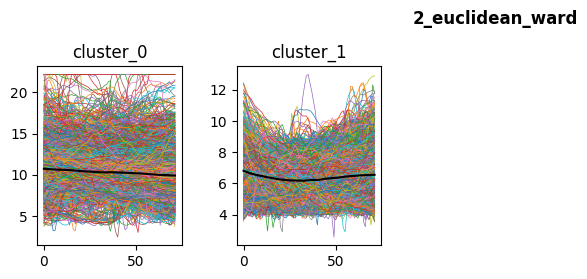

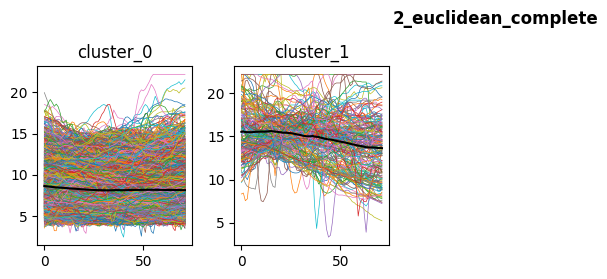

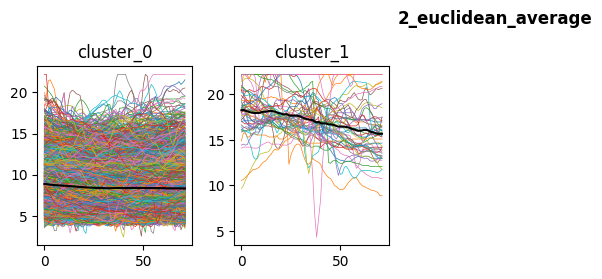

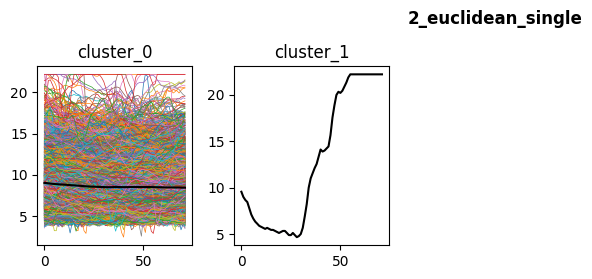

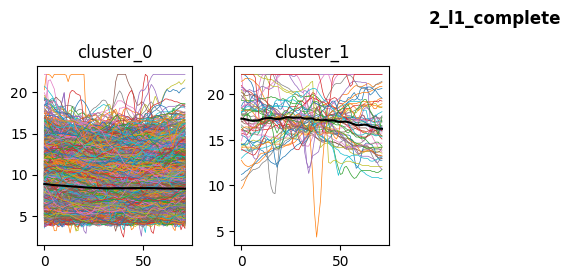

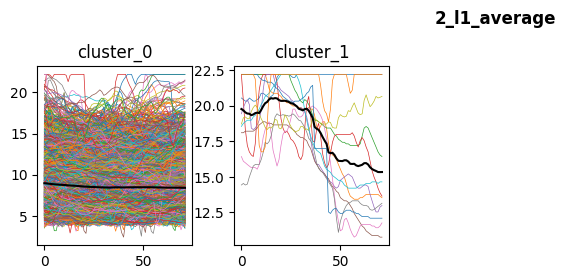

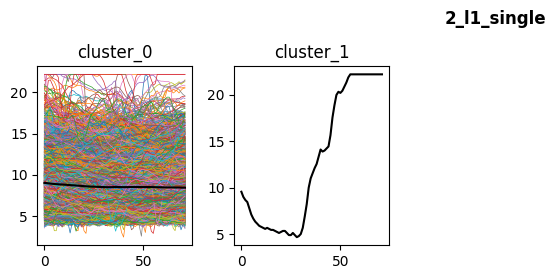

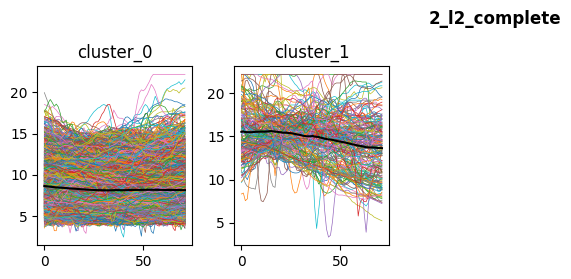

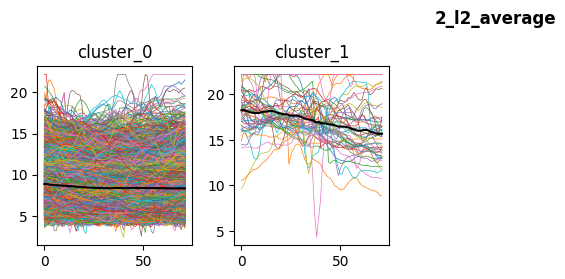

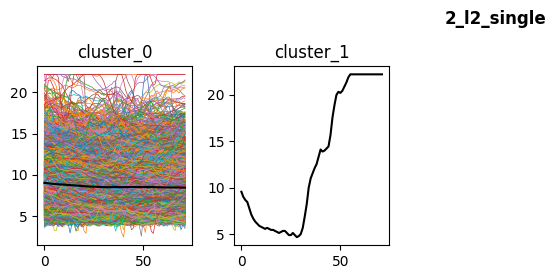

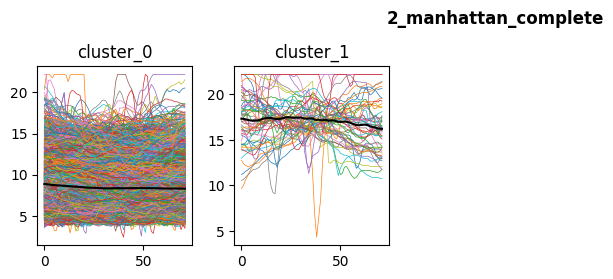

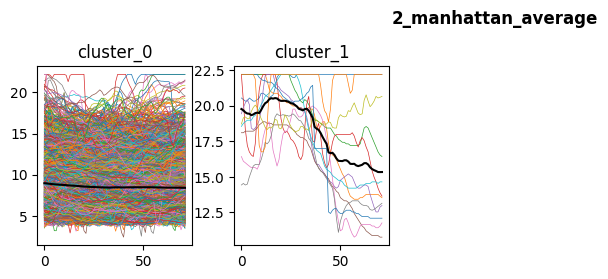

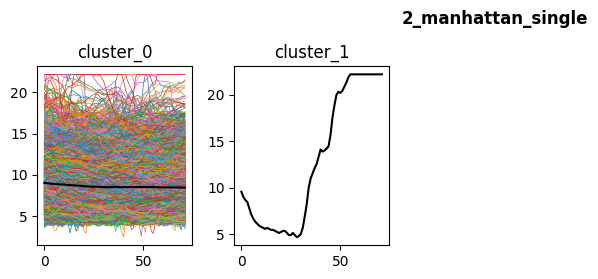

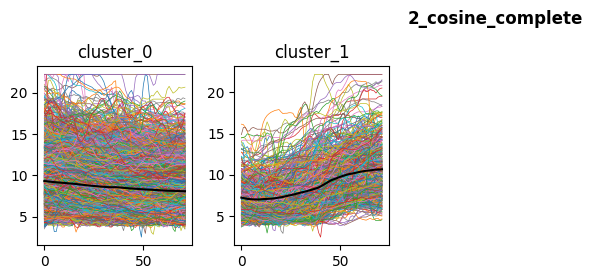

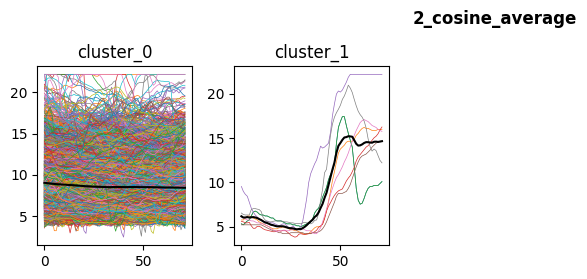

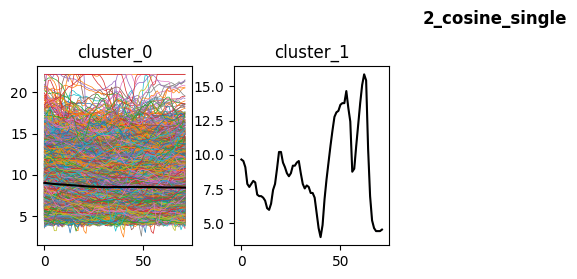

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==2].T)

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==3].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==4].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==5].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==6].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==7].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==8].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==9].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==10].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==11].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==12].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==13].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==14].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0, res_df.T.loc[res_df.T['n_clusters']==15].T)

Output hidden; open in https://colab.research.google.com to view.



---



Относительно неплохая кластеризация.

Стоит отметить, что вне зависимости от кол-ва кластеров комбинация euclidean+ward показывает хорошие результаты.

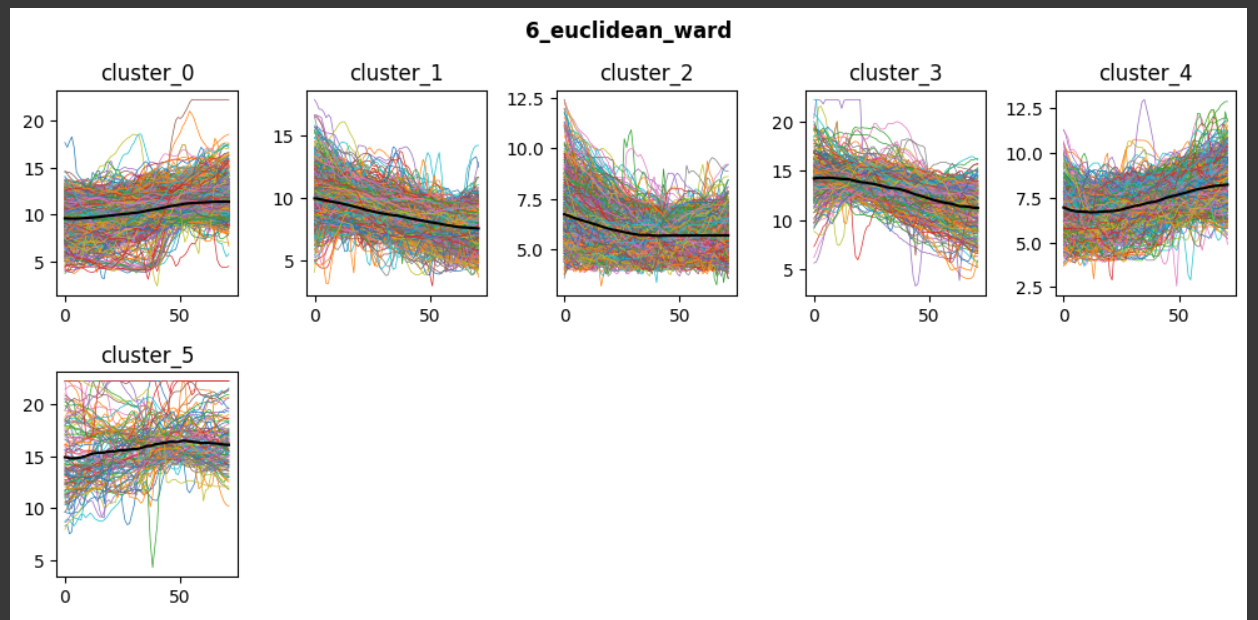

## стандартизация данных

In [ ]:
from sklearn.preprocessing import scale

In [ ]:
df_0_scaled = scale(df_0, axis=1)  # scaling each row independently
df_0_scaled.shape

(3376, 72)

### подбор параметров

In [ ]:
n_clusters = range(2,16)
metric = ['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
linkage = ['ward', 'complete', 'average', 'single']
results = {}

In [ ]:
for n in n_clusters:
  for m in metric:
    for l in linkage:
      if (l == 'ward') & (m != 'euclidean'):
        continue
      ag_clustering = AgC(
            n_clusters=n,
            metric=m,
            linkage=l
        )
      labels = ag_clustering.fit_predict(df_0_scaled)

      silhouette = silhouette_score(df_0_scaled, labels)
      results[str(n)+'_'+m+'_'+l] = {
          'n_clusters': n,
          'metric': m,
          'linkage': l,
          'score': silhouette,
          'labels': labels
      }
      print(f'clusters = {n}, metric = {m}, linkage = {l}: score = {silhouette:.4f}')

clusters = 2, metric = euclidean, linkage = ward: score = 0.3429
clusters = 2, metric = euclidean, linkage = complete: score = 0.3335
clusters = 2, metric = euclidean, linkage = average: score = 0.3595
clusters = 2, metric = euclidean, linkage = single: score = 0.0519
clusters = 2, metric = l1, linkage = complete: score = 0.2952
clusters = 2, metric = l1, linkage = average: score = 0.3513
clusters = 2, metric = l1, linkage = single: score = 0.0519
clusters = 2, metric = l2, linkage = complete: score = 0.3335
clusters = 2, metric = l2, linkage = average: score = 0.3595
clusters = 2, metric = l2, linkage = single: score = 0.0519
clusters = 2, metric = manhattan, linkage = complete: score = 0.2952
clusters = 2, metric = manhattan, linkage = average: score = 0.3513
clusters = 2, metric = manhattan, linkage = single: score = 0.0519
clusters = 2, metric = cosine, linkage = complete: score = 0.3335
clusters = 2, metric = cosine, linkage = average: score = 0.3566
clusters = 2, metric = cosine,

In [ ]:
res_df = pd.DataFrame(results)
res_df

,2_euclidean_ward,2_euclidean_complete,2_euclidean_average,2_euclidean_single,2_l1_complete,2_l1_average,2_l1_single,2_l2_complete,2_l2_average,2_l2_single,...,15_l1_single,15_l2_complete,15_l2_average,15_l2_single,15_manhattan_complete,15_manhattan_average,15_manhattan_single,15_cosine_complete,15_cosine_average,15_cosine_single
n_clusters,2,2,2,2,2,2,2,2,2,2,...,15,15,15,15,15,15,15,15,15,15
metric,euclidean,euclidean,euclidean,euclidean,l1,l1,l1,l2,l2,l2,...,l1,l2,l2,l2,manhattan,manhattan,manhattan,cosine,cosine,cosine
linkage,ward,complete,average,single,complete,average,single,complete,average,single,...,single,complete,average,single,complete,average,single,complete,average,single
score,0.342917,0.333465,0.3595,0.051858,0.295244,0.351348,0.051858,0.333465,0.3595,0.051858,...,-0.12062,0.14053,0.220134,-0.105911,0.152712,0.21643,-0.12062,0.14053,0.252091,-0.105911
labels,"[1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 7, 7, 7, 8, 14, 7, 10, 7, 2, 2, 7, 11, 7, ...","[4, 4, 4, 4, 0, 6, 4, 0, 4, 0, 5, 4, 5, 4, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 9, 0, 1, 0, 1, 1, 0, 10, 0, 3,...","[6, 6, 6, 6, 10, 2, 6, 10, 6, 1, 1, 6, 1, 6, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 7, 7, 7, 8, 14, 7, 10, 7, 2, 2, 7, 11, 7, ...","[0, 0, 0, 0, 3, 10, 0, 3, 0, 3, 3, 0, 1, 0, 5,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### визуализация

In [ ]:
df_0_scaled = pd.DataFrame(df_0_scaled, columns=df_0.columns)

In [ ]:
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==2].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==3].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==4].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==5].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==6].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==7].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==8].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==9].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==10].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==11].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==12].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==13].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==14].T)
draw_plot(df_0_scaled, res_df.T.loc[res_df.T['n_clusters']==15].T)

Output hidden; open in https://colab.research.google.com to view.



---



Сравнительно хорошая кластеризация.

Будем считать, что для иерархической кластеризации оптимальным вариантом будет 6_euclidean_ward.



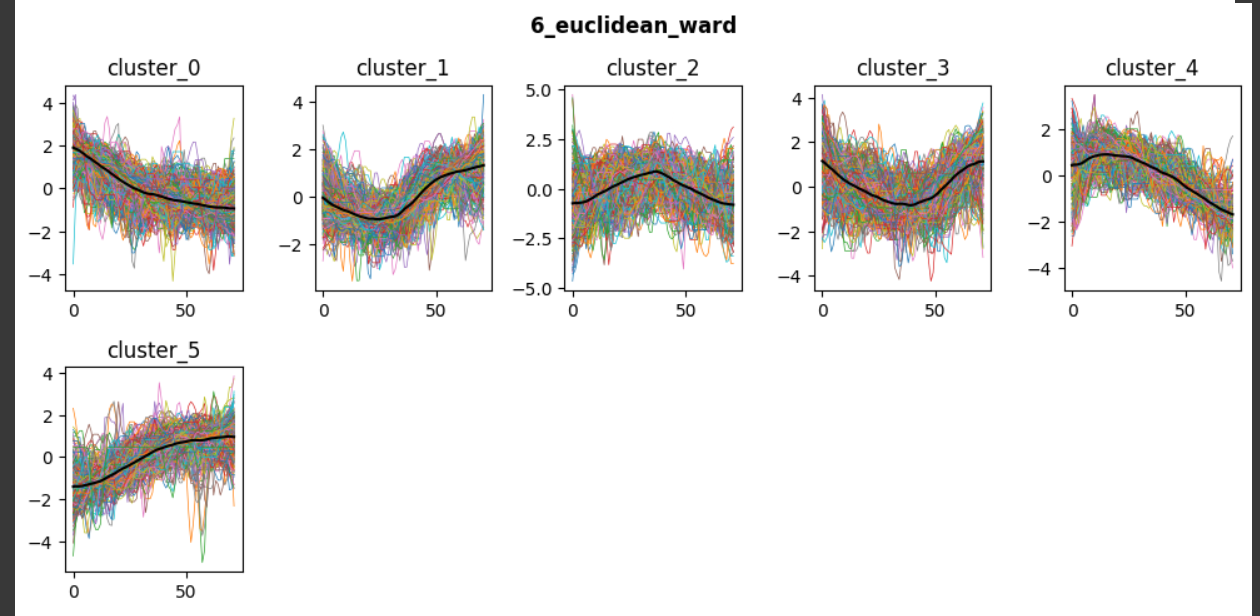

# kmeans (df_0)

In [ ]:
from sklearn.cluster import KMeans as KM

n_clusters=8

In [ ]:
def km_params(data):
  results_km = {}
  for n in range(2,16):
    labels = KM(n_clusters=n).fit(data).labels_
    silhouette = silhouette_score(data, labels)

    results_km['n_clusters_'+str(n)] = {
        'n_clusters': n,
        'score': silhouette,
        'labels': labels
    }

    print(f'clusters = {n}: score = {silhouette:.4f}')

  return results_km

In [ ]:
res_km = km_params(df_0)
res_km = pd.DataFrame(res_km)

clusters = 2: score = 0.4871
clusters = 3: score = 0.3948
clusters = 4: score = 0.3225
clusters = 5: score = 0.2952
clusters = 6: score = 0.2816
clusters = 7: score = 0.2768
clusters = 8: score = 0.2678
clusters = 9: score = 0.2540
clusters = 10: score = 0.2384
clusters = 11: score = 0.2312
clusters = 12: score = 0.2291
clusters = 13: score = 0.2293
clusters = 14: score = 0.2334
clusters = 15: score = 0.2201


In [ ]:
draw_plot(df_0, res_km)

Output hidden; open in https://colab.research.google.com to view.



---



Неплохие варианты на 6 и 7 кластеров

## стандартизация

In [ ]:
res_km = km_params(df_0_scaled)
res_km = pd.DataFrame(res_km)

clusters = 2: score = 0.3936
clusters = 3: score = 0.3412
clusters = 4: score = 0.3096
clusters = 5: score = 0.2217
clusters = 6: score = 0.2086
clusters = 7: score = 0.1722
clusters = 8: score = 0.1678
clusters = 9: score = 0.1574
clusters = 10: score = 0.1699
clusters = 11: score = 0.1485
clusters = 12: score = 0.1351
clusters = 13: score = 0.1367
clusters = 14: score = 0.1257
clusters = 15: score = 0.1143


In [ ]:
draw_plot(df_0_scaled, res_km)

Output hidden; open in https://colab.research.google.com to view.

кластеризация стандартизированных данных выдаёт примерно одинаковые результыты при любом кол-ве кластеров

# dbscan (df_0)

In [ ]:
from sklearn.cluster import DBSCAN

eps=0.5, min_samples=5

In [ ]:
eps = range(2,6)  # The maximum distance between two samples [8, 9, 10]
min_samples = [5, 6, 7, 8, 9]  # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point [6, 7, 8, 9, 10]

In [ ]:
def db_params(data):
  results_db = {}
  for ep in eps:
    for samp in min_samples:
      try:
        labels = DBSCAN(
            eps=ep, min_samples=samp
        ).fit(data).labels_
        silhouette = silhouette_score(data, labels)

        results_db['eps_'+str(ep)+'_min_samp_'+str(samp)] = {
            'eps': ep,
            'min_samples': samp,
            'score': silhouette,
            'labels': labels
        }

        print(f'eps = {ep}, min_samples = {samp}: score = {silhouette:.4f}')

      except ValueError as error:
        print(f'ERROR! eps = {ep}, min_samples = {samp}: {error}')

  return results_db


In [ ]:
res_db = db_params(df_0)
res_db = pd.DataFrame(res_db)

eps = 2, min_samples = 5: score = -0.4884
eps = 2, min_samples = 6: score = -0.2826
eps = 2, min_samples = 7: score = -0.2539
eps = 2, min_samples = 8: score = -0.2616
eps = 2, min_samples = 9: score = -0.2706
eps = 3, min_samples = 5: score = -0.4768
eps = 3, min_samples = 6: score = -0.4751
eps = 3, min_samples = 7: score = -0.4420
eps = 3, min_samples = 8: score = -0.2930
eps = 3, min_samples = 9: score = -0.2483
eps = 4, min_samples = 5: score = -0.2710
eps = 4, min_samples = 6: score = 0.0102
eps = 4, min_samples = 7: score = 0.0334
eps = 4, min_samples = 8: score = 0.0533
eps = 4, min_samples = 9: score = 0.0051
eps = 5, min_samples = 5: score = -0.0693
eps = 5, min_samples = 6: score = 0.2509
eps = 5, min_samples = 7: score = 0.1740
eps = 5, min_samples = 8: score = 0.1656
eps = 5, min_samples = 9: score = 0.1715


In [ ]:
res_db

,eps_2_min_samp_5,eps_2_min_samp_6,eps_2_min_samp_7,eps_2_min_samp_8,eps_2_min_samp_9,eps_3_min_samp_5,eps_3_min_samp_6,eps_3_min_samp_7,eps_3_min_samp_8,eps_3_min_samp_9,eps_4_min_samp_5,eps_4_min_samp_6,eps_4_min_samp_7,eps_4_min_samp_8,eps_4_min_samp_9,eps_5_min_samp_5,eps_5_min_samp_6,eps_5_min_samp_7,eps_5_min_samp_8,eps_5_min_samp_9
eps,2,2,2,2,2,3,3,3,3,3,4,4,4,4,4,5,5,5,5,5
min_samples,5,6,7,8,9,5,6,7,8,9,5,6,7,8,9,5,6,7,8,9
score,-0.488403,-0.282583,-0.253945,-0.261593,-0.270644,-0.476768,-0.475057,-0.442028,-0.293027,-0.248319,-0.270976,0.010249,0.033392,0.053297,0.005051,-0.069323,0.250878,0.174004,0.165595,0.171472
labels,"[-1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 0,...","[-1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 0,...","[-1, -1, -1, -1, -1, -1, 3, -1, -1, -1, -1, 0,...","[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0...","[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...","[0, -1, -1, 0, -1, 0, 0, -1, 0, 0, -1, 0, 0, 0...","[0, -1, -1, 0, -1, 0, 0, -1, 0, 0, -1, 0, 0, 0...","[0, -1, -1, 0, -1, 0, 0, -1, 0, 0, -1, 0, 0, 0...","[0, -1, -1, 0, -1, 0, 0, -1, 0, 0, -1, 0, 0, 0...","[0, -1, -1, 0, -1, 1, 0, -1, 0, 0, -1, 0, 0, 0...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 1, 0, 0, -1, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
def draw_plot_db(data, res):
  for title in res.columns:
    label = res[title]['labels']
    plt.figure(figsize=(10, 7))
    for n in np.unique(label):
      #plt.figure(figsize=(15, 10))
      plt.subplot(4,5,(n+2))
      plt.plot(data[label == n].values.T, linewidth=0.5)
      plt.plot(data[label == n].values.mean(axis=0), color='black')
      plt.title('cluster_'+str(n))
      #plt.tight_layout()
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
draw_plot_db(df_0, res_db)

Output hidden; open in https://colab.research.google.com to view.



---



некрасиво.

дбскан работает неприятно. всё плохо

## стандартизация

In [ ]:
res_db = db_params(df_0_scaled)
res_db = pd.DataFrame(res_db)

eps = 2, min_samples = 5: score = -0.0612
eps = 2, min_samples = 6: score = -0.1371
eps = 2, min_samples = 7: score = -0.1779
eps = 2, min_samples = 8: score = -0.0619
eps = 2, min_samples = 9: score = -0.0150
eps = 3, min_samples = 5: score = 0.0388
eps = 3, min_samples = 6: score = -0.0918
eps = 3, min_samples = 7: score = -0.0911
eps = 3, min_samples = 8: score = 0.0401
eps = 3, min_samples = 9: score = 0.0398
eps = 4, min_samples = 5: score = 0.0538
eps = 4, min_samples = 6: score = 0.0540
eps = 4, min_samples = 7: score = 0.0538
eps = 4, min_samples = 8: score = 0.0535
eps = 4, min_samples = 9: score = 0.0533
eps = 5, min_samples = 5: score = 0.0610
eps = 5, min_samples = 6: score = 0.0610
eps = 5, min_samples = 7: score = 0.0610
eps = 5, min_samples = 8: score = 0.0615
eps = 5, min_samples = 9: score = 0.0614


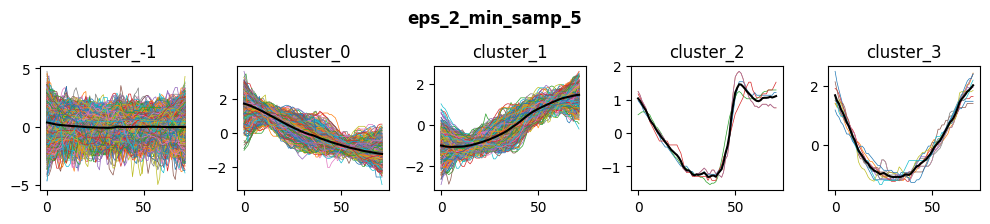

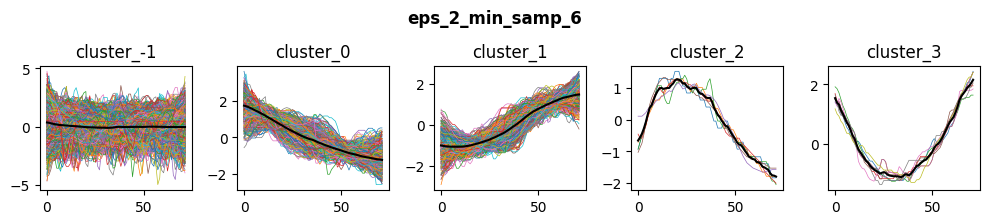

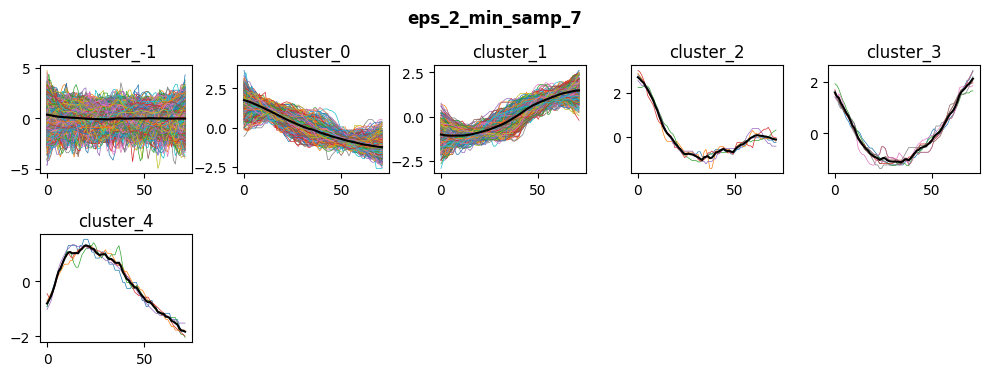

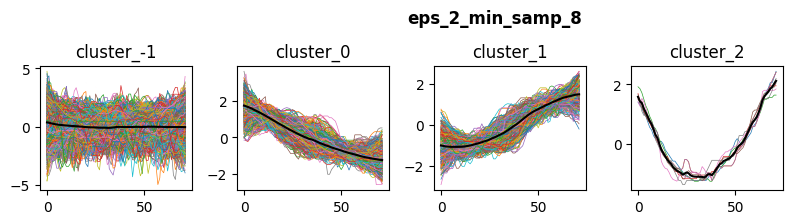

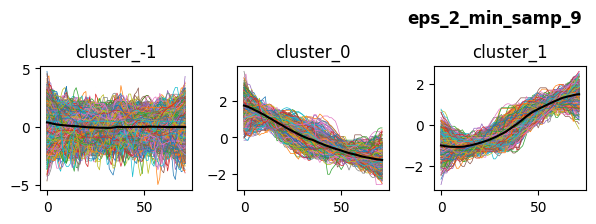

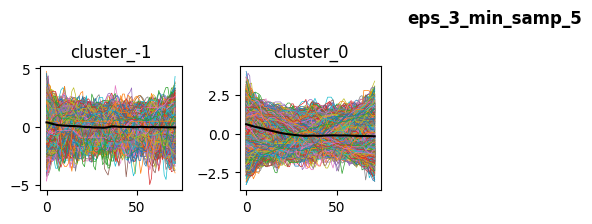

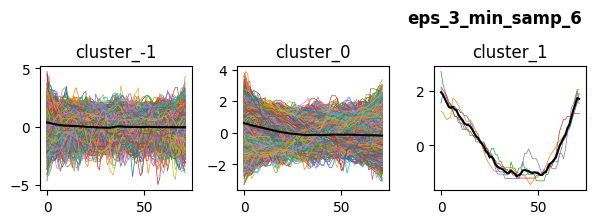

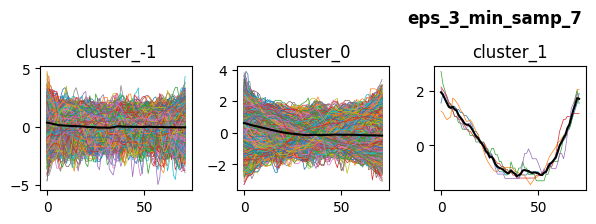

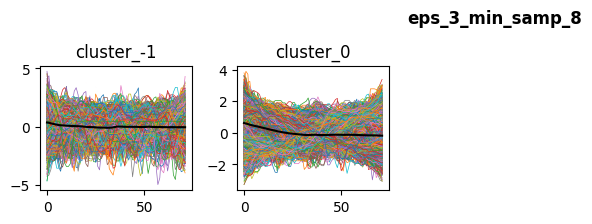

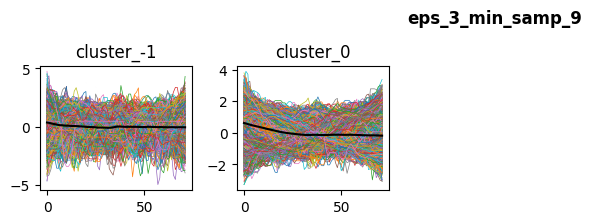

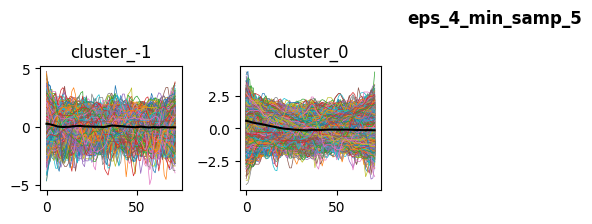

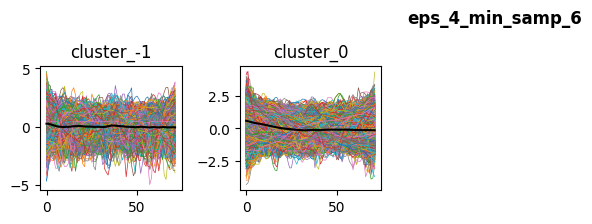

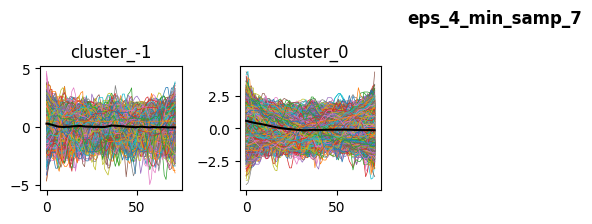

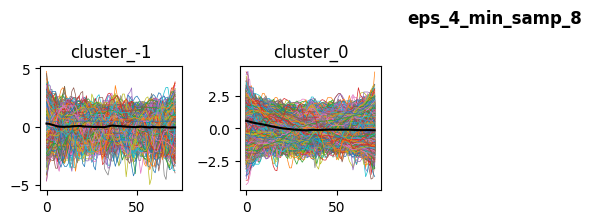

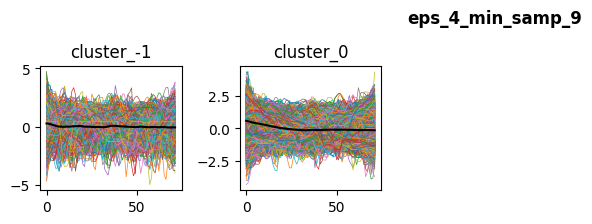

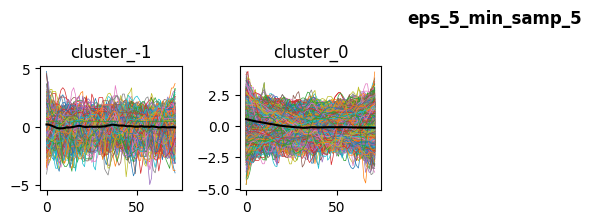

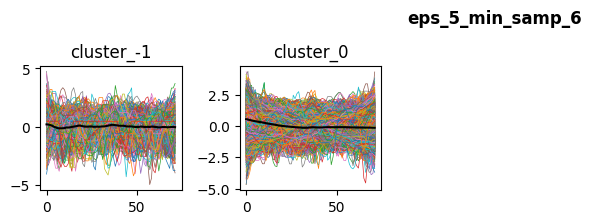

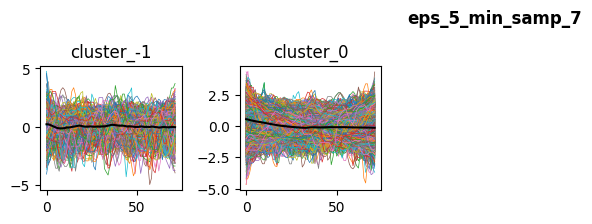

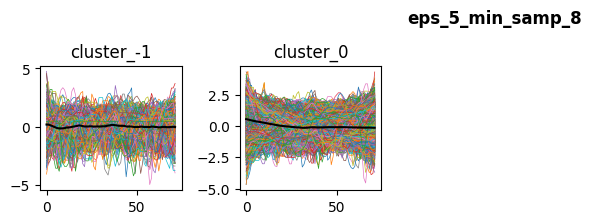

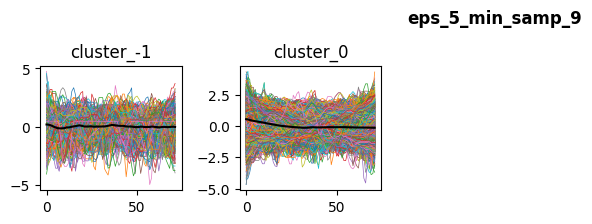

In [ ]:
draw_plot_db(df_0_scaled, res_db)



---



Стандартизация улучшает ситуацию.

наиболее оптимальное разбиение:

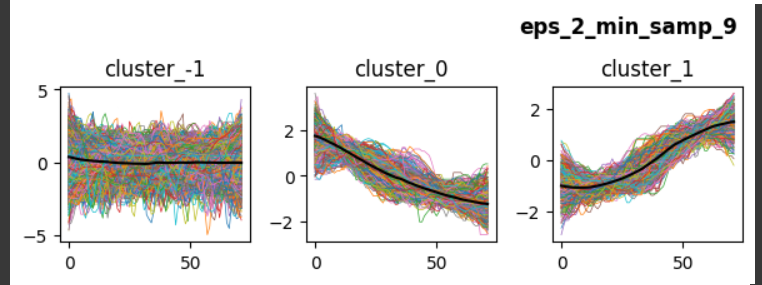




---


---


---




# Иерархическая кластеризация (df_1)

### подбор параметров

In [ ]:
n_clusters = range(2,16)
metric = ['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
linkage = ['ward', 'complete', 'average', 'single']
results = {}

In [ ]:
for n in n_clusters:
  for m in metric:
    for l in linkage:
      if (l == 'ward') & (m != 'euclidean'):
        continue
      ag_clustering = AgC(
            n_clusters=n,
            metric=m,
            linkage=l
        )
      labels = ag_clustering.fit_predict(df_1)

      silhouette = silhouette_score(df_1, labels)
      results[str(n)+'_'+m+'_'+l] = {
          'n_clusters': n,
          'metric': m,
          'linkage': l,
          'score': silhouette,
          'labels': labels
      }
      print(f'clusters = {n}, metric = {m}, linkage = {l}: score = {silhouette:.4f}')

clusters = 2, metric = euclidean, linkage = ward: score = 0.2942
clusters = 2, metric = euclidean, linkage = complete: score = 0.4807
clusters = 2, metric = euclidean, linkage = average: score = 0.5278
clusters = 2, metric = euclidean, linkage = single: score = 0.4975
clusters = 2, metric = l1, linkage = complete: score = 0.5675
clusters = 2, metric = l1, linkage = average: score = 0.5901
clusters = 2, metric = l1, linkage = single: score = 0.6759
clusters = 2, metric = l2, linkage = complete: score = 0.4807
clusters = 2, metric = l2, linkage = average: score = 0.5278
clusters = 2, metric = l2, linkage = single: score = 0.4975
clusters = 2, metric = manhattan, linkage = complete: score = 0.5675
clusters = 2, metric = manhattan, linkage = average: score = 0.5901
clusters = 2, metric = manhattan, linkage = single: score = 0.6759
clusters = 2, metric = cosine, linkage = complete: score = 0.2820
clusters = 2, metric = cosine, linkage = average: score = 0.1743
clusters = 2, metric = cosine,

In [ ]:
res_df = pd.DataFrame(results)
res_df

,2_euclidean_ward,2_euclidean_complete,2_euclidean_average,2_euclidean_single,2_l1_complete,2_l1_average,2_l1_single,2_l2_complete,2_l2_average,2_l2_single,...,15_l1_single,15_l2_complete,15_l2_average,15_l2_single,15_manhattan_complete,15_manhattan_average,15_manhattan_single,15_cosine_complete,15_cosine_average,15_cosine_single
n_clusters,2,2,2,2,2,2,2,2,2,2,...,15,15,15,15,15,15,15,15,15,15
metric,euclidean,euclidean,euclidean,euclidean,l1,l1,l1,l2,l2,l2,...,l1,l2,l2,l2,manhattan,manhattan,manhattan,cosine,cosine,cosine
linkage,ward,complete,average,single,complete,average,single,complete,average,single,...,single,complete,average,single,complete,average,single,complete,average,single
score,0.29423,0.480689,0.52775,0.497543,0.567493,0.590067,0.675942,0.480689,0.52775,0.497543,...,0.272292,0.244958,0.309986,0.266841,0.151174,0.301807,0.272292,0.020118,0.058463,-0.296474
labels,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 2, 2, 2, 9, 2, 9, 2, 2, 2, 2, 2, 3, 3, 11,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 0, 6, 6, 12, 0, 12, 6, 6, 0, 0, 6, 7, 7, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3, 2, 2, 1, 13, 6, 6, 10, 1, 6, 2, 0, 2, 2, 5...","[0, 4, 0, 3, 4, 4, 4, 4, 5, 4, 4, 0, 2, 0, 9, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### визуализация

In [ ]:
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==2].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==3].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==4].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==5].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==6].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==7].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==8].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==9].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==10].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==11].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==12].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==13].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==14].T)
draw_plot(df_1, res_df.T.loc[res_df.T['n_clusters']==15].T)

Output hidden; open in https://colab.research.google.com to view.



---



## стандартизация данных

In [ ]:
df_1_scaled = scale(df_1, axis=1)  # scaling each row independently
df_1_scaled.shape

(449, 72)

### подбор параметров

In [ ]:
n_clusters = range(2,16)
metric = ['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
linkage = ['ward', 'complete', 'average', 'single']
results = {}

In [ ]:
for n in n_clusters:
  for m in metric:
    for l in linkage:
      if (l == 'ward') & (m != 'euclidean'):
        continue
      ag_clustering = AgC(
            n_clusters=n,
            metric=m,
            linkage=l
        )
      labels = ag_clustering.fit_predict(df_1_scaled)

      silhouette = silhouette_score(df_1_scaled, labels)
      results[str(n)+'_'+m+'_'+l] = {
          'n_clusters': n,
          'metric': m,
          'linkage': l,
          'score': silhouette,
          'labels': labels
      }
      print(f'clusters = {n}, metric = {m}, linkage = {l}: score = {silhouette:.4f}')

clusters = 2, metric = euclidean, linkage = ward: score = 0.3147
clusters = 2, metric = euclidean, linkage = complete: score = 0.2994
clusters = 2, metric = euclidean, linkage = average: score = 0.3432
clusters = 2, metric = euclidean, linkage = single: score = 0.0940
clusters = 2, metric = l1, linkage = complete: score = 0.3118
clusters = 2, metric = l1, linkage = average: score = 0.3502
clusters = 2, metric = l1, linkage = single: score = 0.0986
clusters = 2, metric = l2, linkage = complete: score = 0.2994
clusters = 2, metric = l2, linkage = average: score = 0.3432
clusters = 2, metric = l2, linkage = single: score = 0.0940
clusters = 2, metric = manhattan, linkage = complete: score = 0.3118
clusters = 2, metric = manhattan, linkage = average: score = 0.3502
clusters = 2, metric = manhattan, linkage = single: score = 0.0986
clusters = 2, metric = cosine, linkage = complete: score = 0.2994
clusters = 2, metric = cosine, linkage = average: score = 0.3524
clusters = 2, metric = cosine,

In [ ]:
res_df = pd.DataFrame(results)
res_df

,2_euclidean_ward,2_euclidean_complete,2_euclidean_average,2_euclidean_single,2_l1_complete,2_l1_average,2_l1_single,2_l2_complete,2_l2_average,2_l2_single,...,15_l1_single,15_l2_complete,15_l2_average,15_l2_single,15_manhattan_complete,15_manhattan_average,15_manhattan_single,15_cosine_complete,15_cosine_average,15_cosine_single
n_clusters,2,2,2,2,2,2,2,2,2,2,...,15,15,15,15,15,15,15,15,15,15
metric,euclidean,euclidean,euclidean,euclidean,l1,l1,l1,l2,l2,l2,...,l1,l2,l2,l2,manhattan,manhattan,manhattan,cosine,cosine,cosine
linkage,ward,complete,average,single,complete,average,single,complete,average,single,...,single,complete,average,single,complete,average,single,complete,average,single
score,0.314678,0.29942,0.343181,0.094021,0.311802,0.350209,0.098635,0.29942,0.343181,0.094021,...,-0.127413,0.163017,0.22186,-0.141757,0.15004,0.218775,-0.127413,0.163017,0.231585,-0.141757
labels,"[0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, ...","[1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, ...","[0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...","[0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, ...","[0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 13, 4, 6, 13, 13, 13, 5, 3, 5, 13, 7, 4, ...","[4, 7, 6, 4, 7, 7, 7, 7, 9, 7, 7, 3, 3, 8, 4, ...","[0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[5, 8, 14, 2, 8, 8, 8, 8, 0, 8, 8, 1, 1, 6, 7,...","[3, 13, 0, 2, 13, 13, 13, 2, 12, 13, 13, 7, 7,...","[0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 13, 4, 6, 13, 13, 13, 5, 3, 5, 13, 7, 4, ...","[4, 1, 6, 4, 1, 1, 1, 1, 2, 1, 1, 9, 9, 0, 4, ...","[0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


### визуализация

In [ ]:
df_1_scaled = pd.DataFrame(df_1_scaled, columns=df_1.columns)

In [ ]:
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==2].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==3].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==4].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==5].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==6].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==7].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==8].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==9].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==10].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==11].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==12].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==13].T)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==14].T)
draw_plot(df_1_scaled, res_df.T.loc[res_df.T['n_clusters']==15].T)

Output hidden; open in https://colab.research.google.com to view.

# kmeans (df_1)

In [ ]:
res_km = km_params(df_1)
res_km = pd.DataFrame(res_km)

clusters = 2: score = 0.4272
clusters = 3: score = 0.3281
clusters = 4: score = 0.3233
clusters = 5: score = 0.2379
clusters = 6: score = 0.2411
clusters = 7: score = 0.2348
clusters = 8: score = 0.2285
clusters = 9: score = 0.1933
clusters = 10: score = 0.1920
clusters = 11: score = 0.2200
clusters = 12: score = 0.1817
clusters = 13: score = 0.1899
clusters = 14: score = 0.1847
clusters = 15: score = 0.1824


In [ ]:
draw_plot(df_1, res_km)

Output hidden; open in https://colab.research.google.com to view.

## стандартизация

In [ ]:
res_km = km_params(df_1_scaled)
res_km = pd.DataFrame(res_km)

clusters = 2: score = 0.3758
clusters = 3: score = 0.3078
clusters = 4: score = 0.2725
clusters = 5: score = 0.2109
clusters = 6: score = 0.2153
clusters = 7: score = 0.2425
clusters = 8: score = 0.1580
clusters = 9: score = 0.1440
clusters = 10: score = 0.1673
clusters = 11: score = 0.1466
clusters = 12: score = 0.1680
clusters = 13: score = 0.1574
clusters = 14: score = 0.1610
clusters = 15: score = 0.1410


In [ ]:
draw_plot(df_1_scaled, res_km)

Output hidden; open in https://colab.research.google.com to view.

# dbscan (df_1)

In [ ]:
eps = range(2,6)  # The maximum distance between two samples [8, 9, 10]
min_samples = [5, 6, 7, 8, 9]  # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point [6, 7, 8, 9, 10]

In [ ]:
res_db = db_params(df_1)
res_db = pd.DataFrame(res_db)

ERROR! eps = 2, min_samples = 5: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
ERROR! eps = 2, min_samples = 6: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
ERROR! eps = 2, min_samples = 7: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
ERROR! eps = 2, min_samples = 8: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
ERROR! eps = 2, min_samples = 9: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
eps = 3, min_samples = 5: score = -0.3087
eps = 3, min_samples = 6: score = -0.2971
eps = 3, min_samples = 7: score = -0.2968
eps = 3, min_samples = 8: score = -0.3079
eps = 3, min_samples = 9: score = -0.2671
eps = 4, min_samples = 5: score = -0.2272
eps = 4, min_samples = 6: score = -0.1411
eps = 4, min_samples = 7: score = -0.1477
eps = 4, min_samples = 8: score = -0.0647
eps = 4, min_samples = 9: score = -0.0661
eps = 5, min_samples = 5: score = -0.0782
eps = 5, min_sampl

In [ ]:
res_db

,eps_3_min_samp_5,eps_3_min_samp_6,eps_3_min_samp_7,eps_3_min_samp_8,eps_3_min_samp_9,eps_4_min_samp_5,eps_4_min_samp_6,eps_4_min_samp_7,eps_4_min_samp_8,eps_4_min_samp_9,eps_5_min_samp_5,eps_5_min_samp_6,eps_5_min_samp_7,eps_5_min_samp_8,eps_5_min_samp_9
eps,3,3,3,3,3,4,4,4,4,4,5,5,5,5,5
min_samples,5,6,7,8,9,5,6,7,8,9,5,6,7,8,9
score,-0.308698,-0.297143,-0.296759,-0.307945,-0.267131,-0.227153,-0.141104,-0.147721,-0.064659,-0.06612,-0.078235,0.100221,0.097987,-0.088901,-0.156611
labels,"[-1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[-1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[-1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[-1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[-1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ...","[0, 0, -1, 1, -1, 0, 0, -1, -1, -1, 0, -1, -1,...","[0, 0, -1, -1, -1, 0, 0, -1, -1, -1, 0, -1, -1...","[0, 0, -1, -1, -1, 0, 0, -1, -1, -1, 0, -1, -1...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ...","[-1, 0, -1, -1, -1, 0, -1, -1, -1, -1, 0, -1, ..."


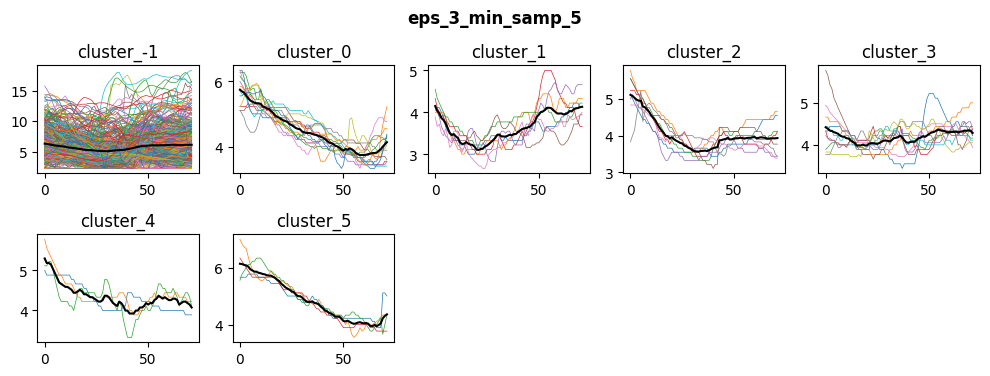

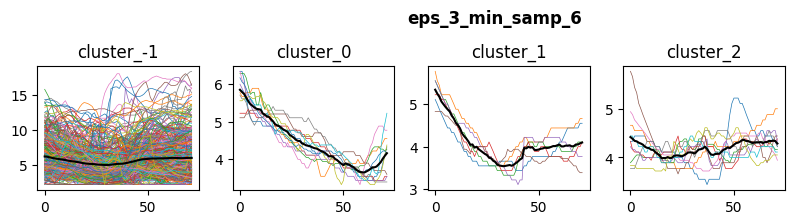

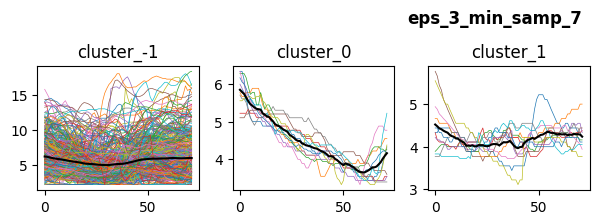

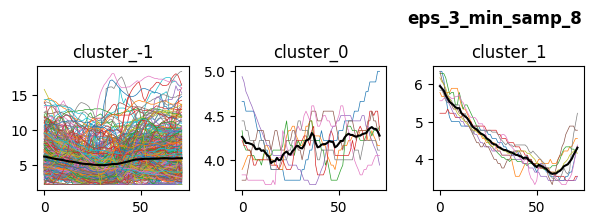

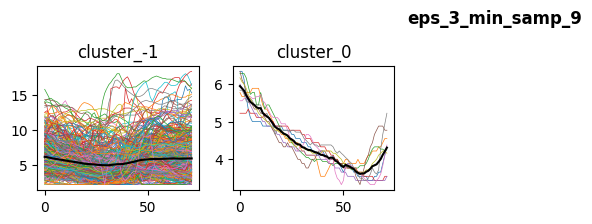

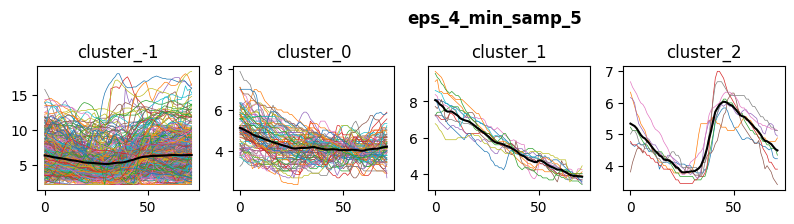

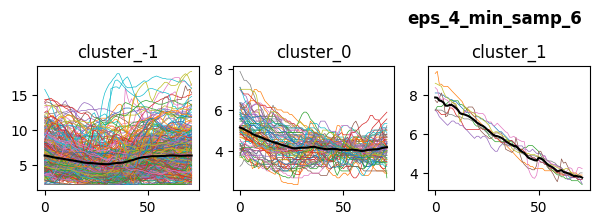

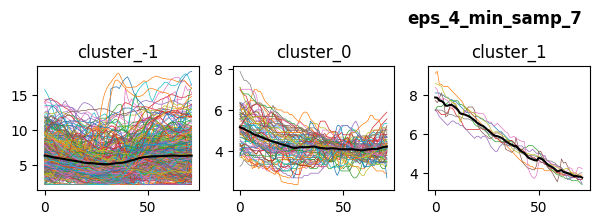

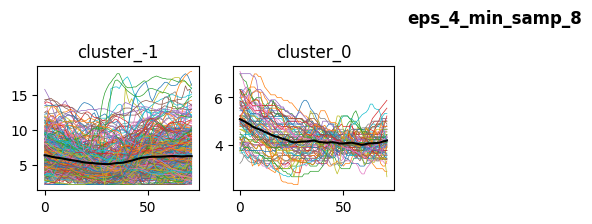

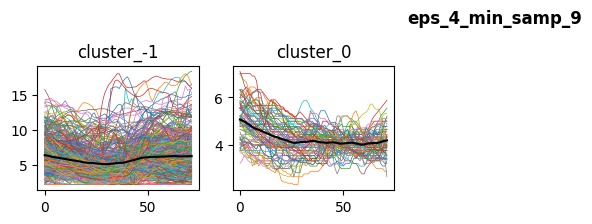

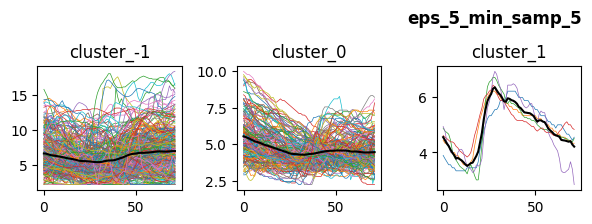

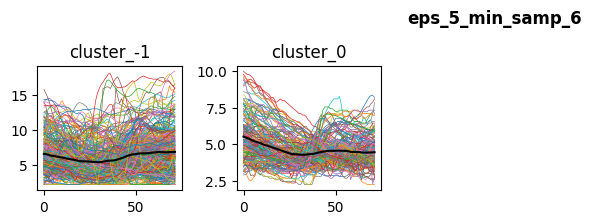

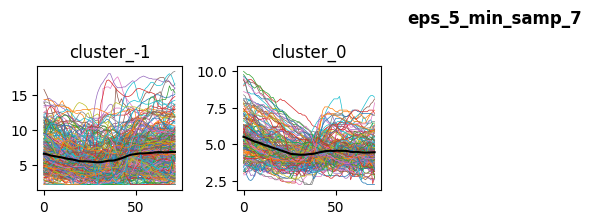

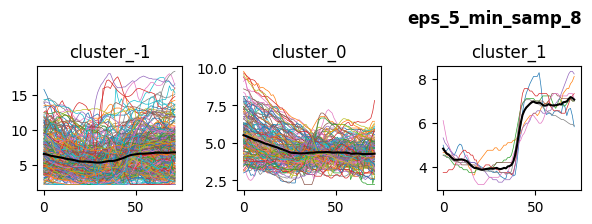

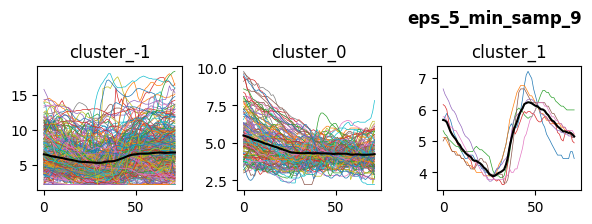

In [ ]:
draw_plot_db(df_1, res_db)

## стандартизация

In [ ]:
res_db = db_params(df_1_scaled)
res_db = pd.DataFrame(res_db)

eps = 2, min_samples = 5: score = -0.1686
eps = 2, min_samples = 6: score = -0.1773
eps = 2, min_samples = 7: score = -0.1887
eps = 2, min_samples = 8: score = -0.2378
eps = 2, min_samples = 9: score = -0.2230
eps = 3, min_samples = 5: score = 0.0946
eps = 3, min_samples = 6: score = 0.0923
eps = 3, min_samples = 7: score = 0.0900
eps = 3, min_samples = 8: score = 0.0153
eps = 3, min_samples = 9: score = 0.0076
eps = 4, min_samples = 5: score = 0.0510
eps = 4, min_samples = 6: score = 0.0511
eps = 4, min_samples = 7: score = 0.0500
eps = 4, min_samples = 8: score = 0.2203
eps = 4, min_samples = 9: score = 0.2220
eps = 5, min_samples = 5: score = 0.0579
eps = 5, min_samples = 6: score = 0.0600
eps = 5, min_samples = 7: score = 0.0625
eps = 5, min_samples = 8: score = 0.0672
eps = 5, min_samples = 9: score = 0.0672


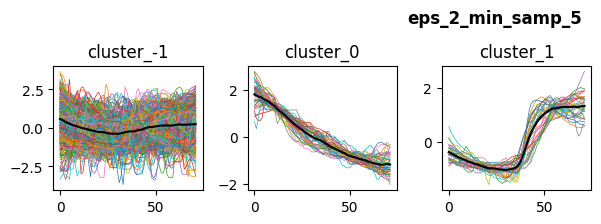

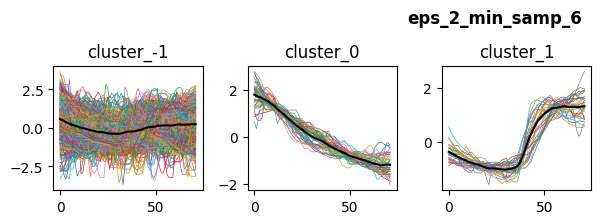

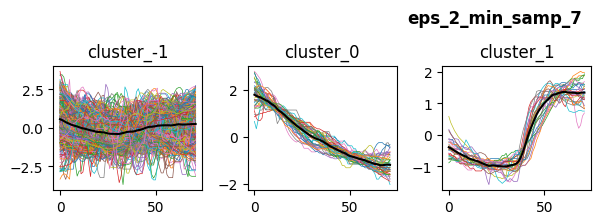

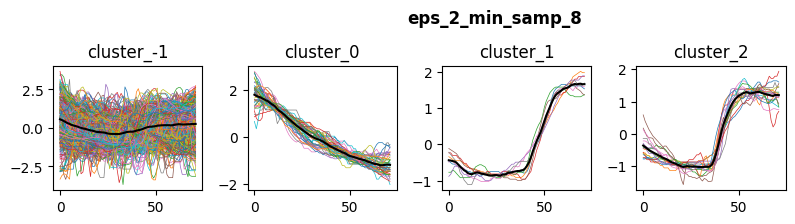

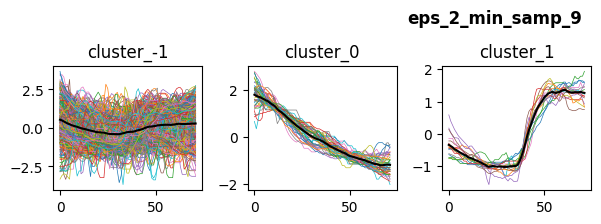

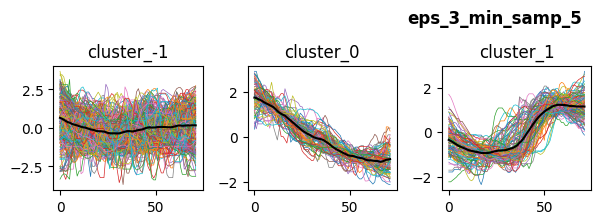

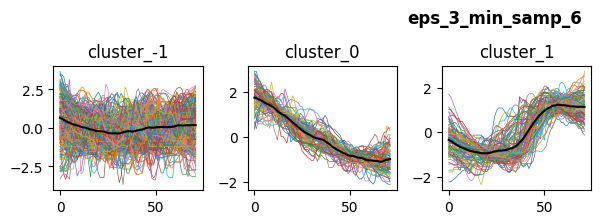

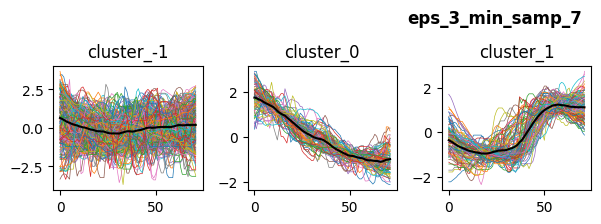

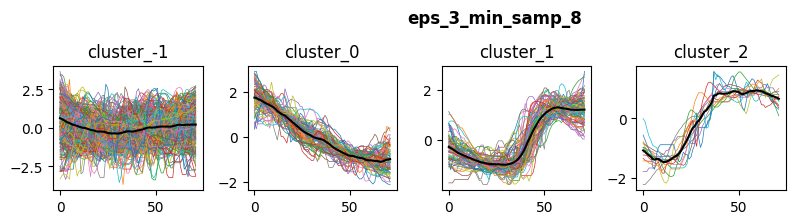

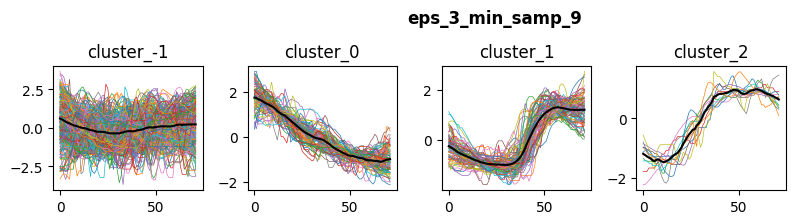

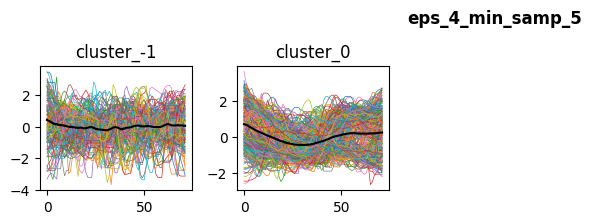

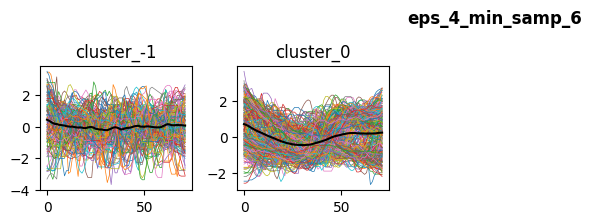

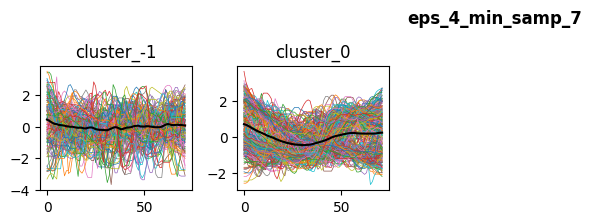

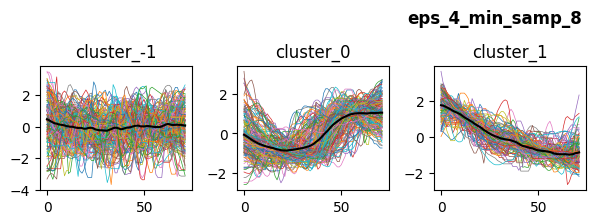

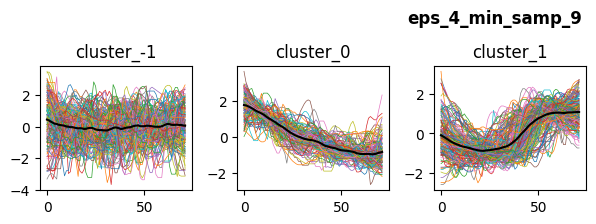

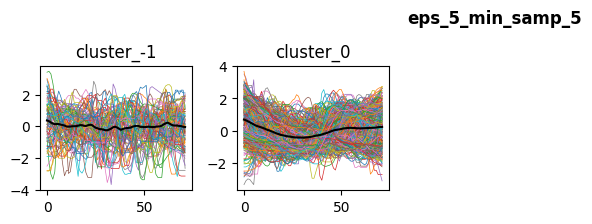

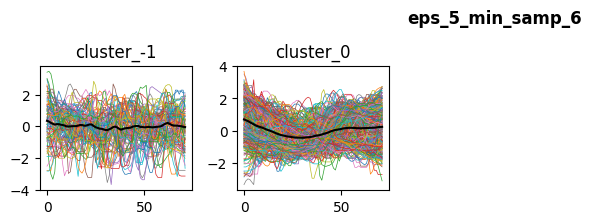

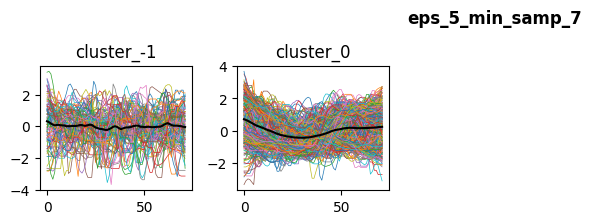

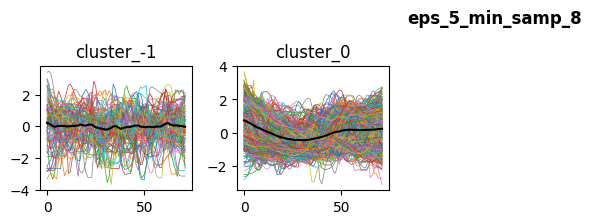

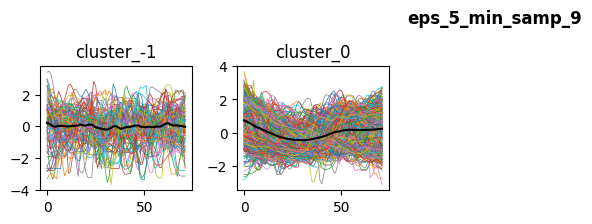

In [ ]:
draw_plot_db(df_1_scaled, res_db)




---


---


---




# Вывод

1. Для иерархической кластеризации комбинация euclidean+ward выдаёт стабильно одни из лучших результатов
2. kmeans: много выбросов в кластерах
3. Стандартизация сильно улучшает работу дбскана
4. Так как df_1 меньше, сложнее нормально оценить кластеризацию по визуализации